<a href="https://colab.research.google.com/github/cabreonictor/Visualizacion-y-Narrativa-de-Datos/blob/main/TP1/Vis_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

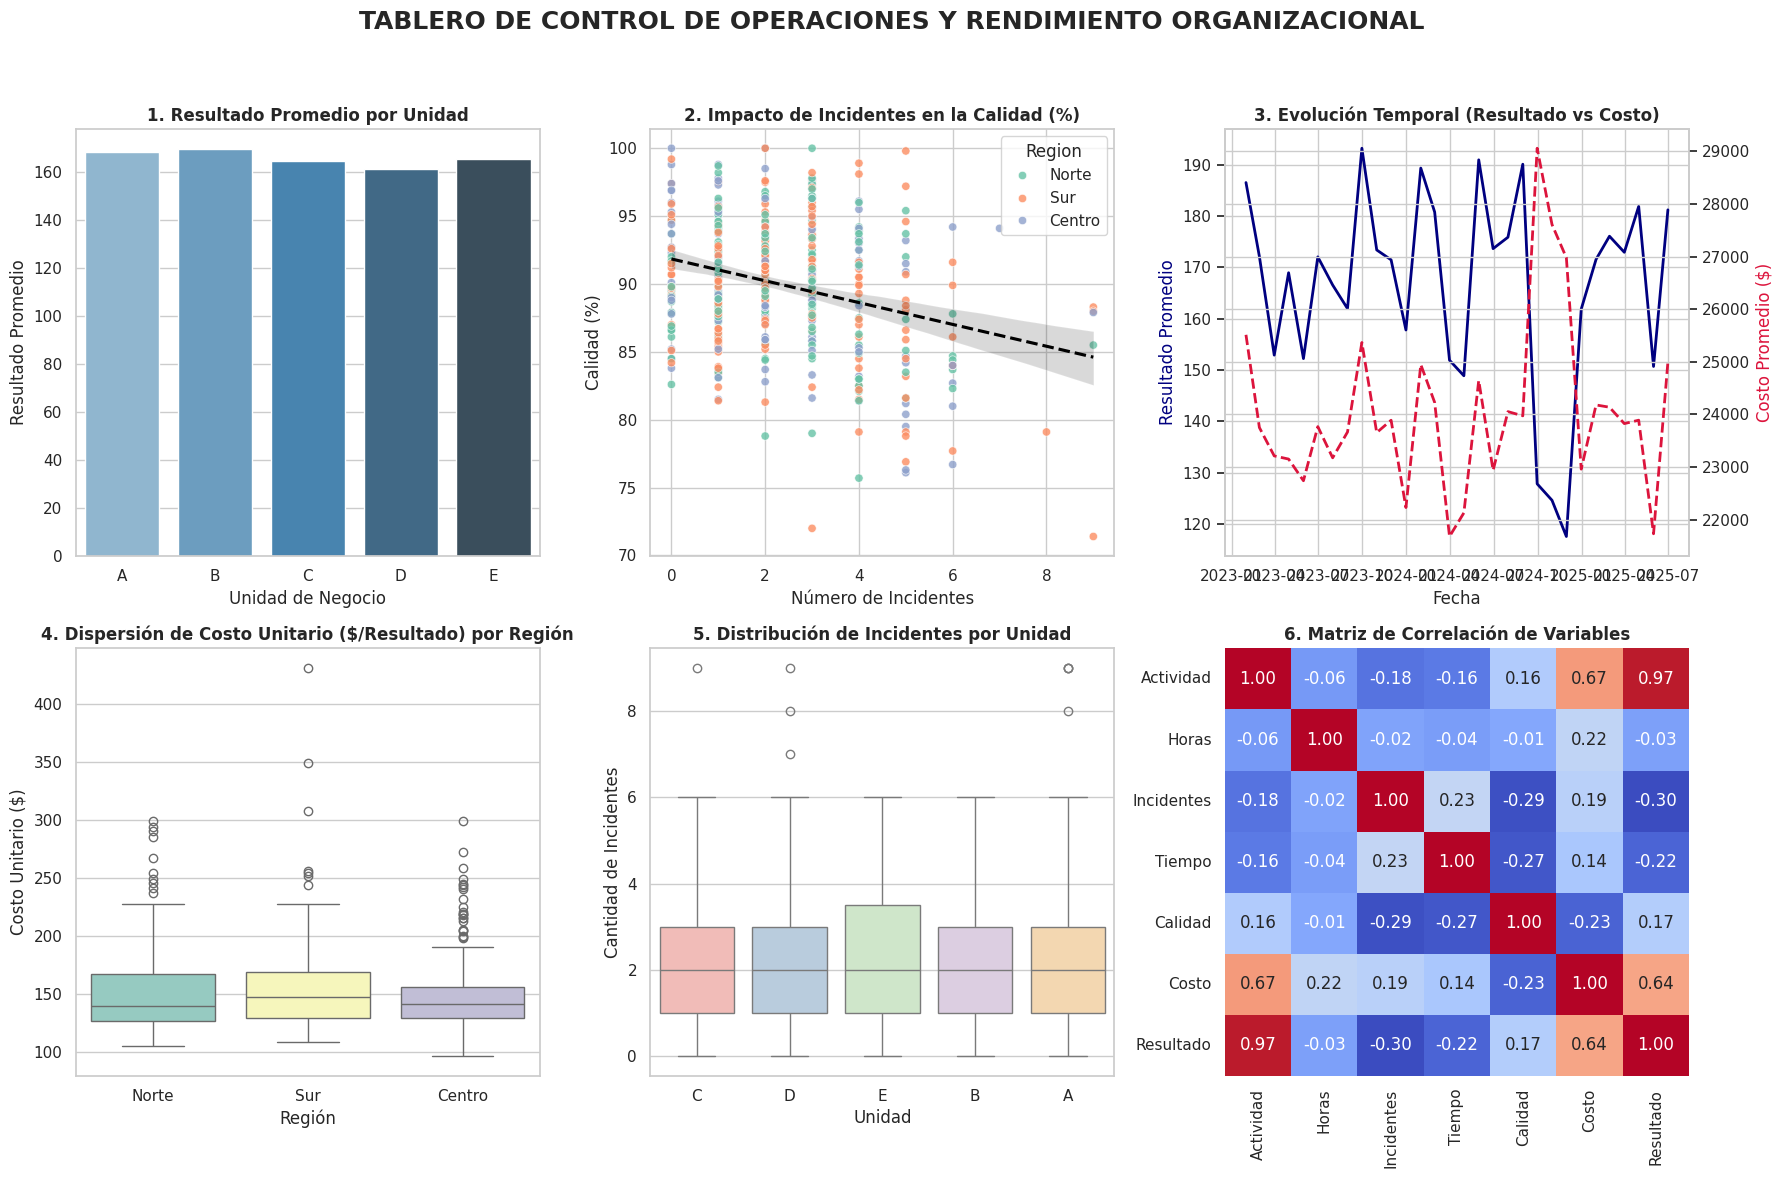

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo y compatibilidad de tipografías (Windows / Colab / Linux)
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial', 'Segoe UI', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

# 1. Cargar y limpiar datos
df = pd.read_csv('https://raw.githubusercontent.com/cabreonictor/Visualizacion-y-Narrativa-de-Datos/refs/heads/main/TP1/operacion_organizacion.csv')
df = df.drop_duplicates()
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Crear variables métricas derivadas
df['Costo_Unitario'] = df['Costo'] / df['Resultado']
df['Productividad_Hora'] = df['Resultado'] / df['Horas']

# 2. Configurar la figura del Dashboard
fig = plt.figure(figsize=(18, 12))
fig.suptitle('TABLERO DE CONTROL DE OPERACIONES Y RENDIMIENTO ORGANIZACIONAL', fontsize=18, fontweight='bold', y=0.98)

# Gráfico 1: Resultado Promedio por Unidad (Actualizado con hue y legend=False)
ax1 = plt.subplot(2, 3, 1)
unidad_metrics = df.groupby('Unidad')[['Resultado', 'Costo_Unitario']].mean().reset_index()
sns.barplot(
    data=unidad_metrics,
    x='Unidad',
    y='Resultado',
    hue='Unidad',
    palette='Blues_d',
    legend=False,
    ax=ax1
)
ax1.set_title('1. Resultado Promedio por Unidad', fontsize=12, fontweight='bold')
ax1.set_ylabel('Resultado Promedio')
ax1.set_xlabel('Unidad de Negocio')

# Gráfico 2: Relación Incidentes vs Calidad
ax2 = plt.subplot(2, 3, 2)
sns.scatterplot(data=df, x='Incidentes', y='Calidad', hue='Region', palette='Set2', alpha=0.8, ax=ax2)
sns.regplot(data=df, x='Incidentes', y='Calidad', scatter=False, ax=ax2, color='black', line_kws={'linestyle': '--'})
ax2.set_title('2. Impacto de Incidentes en la Calidad (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Incidentes')
ax2.set_ylabel('Calidad (%)')

# Gráfico 3: Evolución Temporal (Resultado vs Costo)
ax3 = plt.subplot(2, 3, 3)
df_monthly = df.resample('ME', on='Fecha')[['Resultado', 'Costo']].mean().reset_index()
ax3.plot(df_monthly['Fecha'], df_monthly['Resultado'], label='Resultado', color='navy', linewidth=2)
ax3_twin = ax3.twinx()
ax3_twin.plot(df_monthly['Fecha'], df_monthly['Costo'], label='Costo ($)', color='crimson', linestyle='--', linewidth=2)
ax3.set_title('3. Evolución Temporal (Resultado vs Costo)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Fecha')
ax3.set_ylabel('Resultado Promedio', color='navy')
ax3_twin.set_ylabel('Costo Promedio ($)', color='crimson')

# Gráfico 4: Costo Unitario por Región (Actualizado con hue y legend=False)
ax4 = plt.subplot(2, 3, 4)
sns.boxplot(
    data=df,
    x='Region',
    y='Costo_Unitario',
    hue='Region',
    palette='Set3',
    legend=False,
    ax=ax4
)
ax4.set_title('4. Dispersión de Costo Unitario ($/Resultado) por Región', fontsize=12, fontweight='bold')
ax4.set_xlabel('Región')
ax4.set_ylabel('Costo Unitario ($)')

# Gráfico 5: Distribución de Incidentes por Unidad (Actualizado con hue y legend=False)
ax5 = plt.subplot(2, 3, 5)
sns.boxplot(
    data=df,
    x='Unidad',
    y='Incidentes',
    hue='Unidad',
    palette='Pastel1',
    legend=False,
    ax=ax5
)
ax5.set_title('5. Distribución de Incidentes por Unidad', fontsize=12, fontweight='bold')
ax5.set_xlabel('Unidad')
ax5.set_ylabel('Cantidad de Incidentes')

# Gráfico 6: Mapa de Calor de Correlaciones Operativas
ax6 = plt.subplot(2, 3, 6)
corr_cols = ['Actividad', 'Horas', 'Incidentes', 'Tiempo', 'Calidad', 'Costo', 'Resultado']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=ax6, cbar=False)
ax6.set_title('6. Matriz de Correlación de Variables', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()